In [4]:
import pandas as pd

df = pd.read_csv("CodeAlpha_Sentiment_Reviews.csv")

df.head()

,Review_ID,Product,Review,Rating
0,R001,Wireless Earbuds,The sound quality is excellent and the battery...,5
1,R002,Wireless Earbuds,Very comfortable and easy to connect. I love t...,5
2,R003,Wireless Earbuds,The audio is clear but the charging case feels...,3
3,R004,Wireless Earbuds,Stopped working after one week. Very disappoin...,1
4,R005,Wireless Earbuds,Amazing sound for the price. Highly recommended.,5


In [5]:
import os
print(os.getcwd())

c:\Users\Admin\Desktop\CodeAlpha_EDA\Task_3_Sentiment_Analysis\data


In [6]:
df.shape

(100, 4)

In [7]:
df.columns

Index(['Review_ID', 'Product', 'Review', 'Rating'], dtype='str')

In [8]:
df.isnull().sum()

Review_ID    0
Product      0
Review       0
Rating       0
dtype: int64

In [9]:
df["Rating"].value_counts().sort_index()

Rating
1    15
2    15
3    22
4    10
5    38
Name: count, dtype: int64

In [10]:
%pip install -U textblob

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
from textblob import TextBlob

In [12]:
TextBlob("I love this product").sentiment

Sentiment(polarity=0.5, subjectivity=0.6)

In [13]:
def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity
    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

df["Sentiment"] = df["Review"].apply(get_sentiment)

df[["Review", "Rating", "Sentiment"]].head(10)

,Review,Rating,Sentiment
0,The sound quality is excellent and the battery...,5,Positive
1,Very comfortable and easy to connect. I love t...,5,Positive
2,The audio is clear but the charging case feels...,3,Positive
3,Stopped working after one week. Very disappoin...,1,Negative
4,Amazing sound for the price. Highly recommended.,5,Positive
5,The camera takes beautiful photos and the phon...,5,Positive
6,"Battery life is good, but the phone gets warm ...",3,Positive
7,The screen broke easily and customer service w...,1,Positive
8,Excellent performance and a beautiful display.,5,Positive
9,"It is okay for everyday use, nothing special.",3,Positive


In [14]:
sentiment_counts = df["Sentiment"].value_counts()

print(sentiment_counts)

Sentiment
Positive    66
Negative    25
Neutral      9
Name: count, dtype: int64


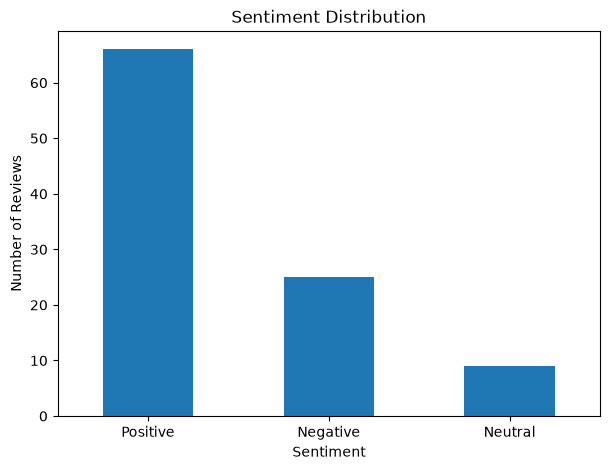

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

sentiment_counts.plot(kind="bar")

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)

plt.show()

In [16]:
sentiment_percentage = df["Sentiment"].value_counts(normalize=True) * 100

print(sentiment_percentage.round(2))

Sentiment
Positive    66.0
Negative    25.0
Neutral      9.0
Name: proportion, dtype: float64


In [17]:
emotion_words = {
    "Joy": [
        "excellent", "amazing", "love", "beautiful", "fantastic",
        "great", "perfect", "happy", "impressive"
    ],
    
    "Anger": [
        "terrible", "frustrating", "angry", "annoying",
        "worst", "disappointing", "unhelpful"
    ],
    
    "Sadness": [
        "disappointing", "sad", "broken", "failed",
        "stopped", "poor"
    ],
    
    "Fear": [
        "dangerous", "worried", "afraid", "risk",
        "unsafe", "problem"
    ]
}


def detect_emotion(text):
    text = text.lower()

    emotion_scores = {}

    for emotion, words in emotion_words.items():
        score = sum(word in text for word in words)
        emotion_scores[emotion] = score

    max_score = max(emotion_scores.values())

    if max_score == 0:
        return "Neutral"

    return max(emotion_scores, key=emotion_scores.get)


df["Emotion"] = df["Review"].apply(detect_emotion)

df[["Review", "Sentiment", "Emotion"]].head(10)

,Review,Sentiment,Emotion
0,The sound quality is excellent and the battery...,Positive,Joy
1,Very comfortable and easy to connect. I love t...,Positive,Joy
2,The audio is clear but the charging case feels...,Positive,Neutral
3,Stopped working after one week. Very disappoin...,Negative,Sadness
4,Amazing sound for the price. Highly recommended.,Positive,Joy
5,The camera takes beautiful photos and the phon...,Positive,Joy
6,"Battery life is good, but the phone gets warm ...",Positive,Neutral
7,The screen broke easily and customer service w...,Positive,Anger
8,Excellent performance and a beautiful display.,Positive,Joy
9,"It is okay for everyday use, nothing special.",Positive,Neutral


In [18]:
emotion_counts = df["Emotion"].value_counts()

print(emotion_counts)

Emotion
Neutral    62
Joy        26
Sadness     6
Anger       6
Name: count, dtype: int64


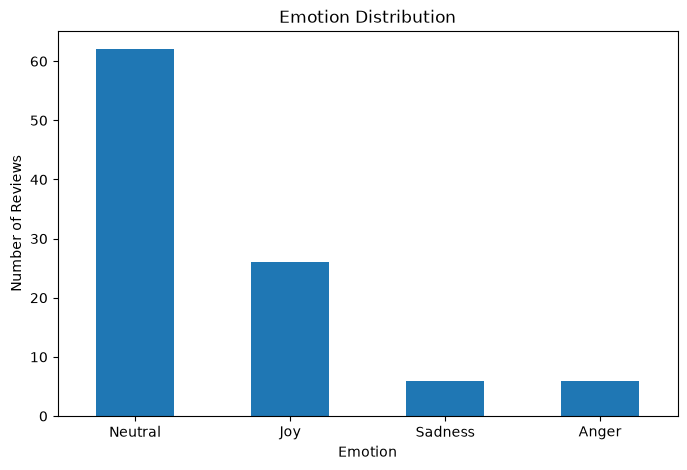

In [19]:
plt.figure(figsize=(8, 5))

emotion_counts.plot(kind="bar")

plt.title("Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)

plt.show()

In [20]:
product_sentiment = pd.crosstab(df["Product"], df["Sentiment"])

product_sentiment


Sentiment,Negative,Neutral,Positive
Product,,,
Bluetooth Speaker,1,0,4
Fitness Band,1,1,3
Gaming Mouse,2,0,3
Headphones,2,0,3
Keyboard,0,1,4
Laptop,1,0,4
Mechanical Keyboard,1,1,3
Monitor,2,0,3
Mouse,2,0,3


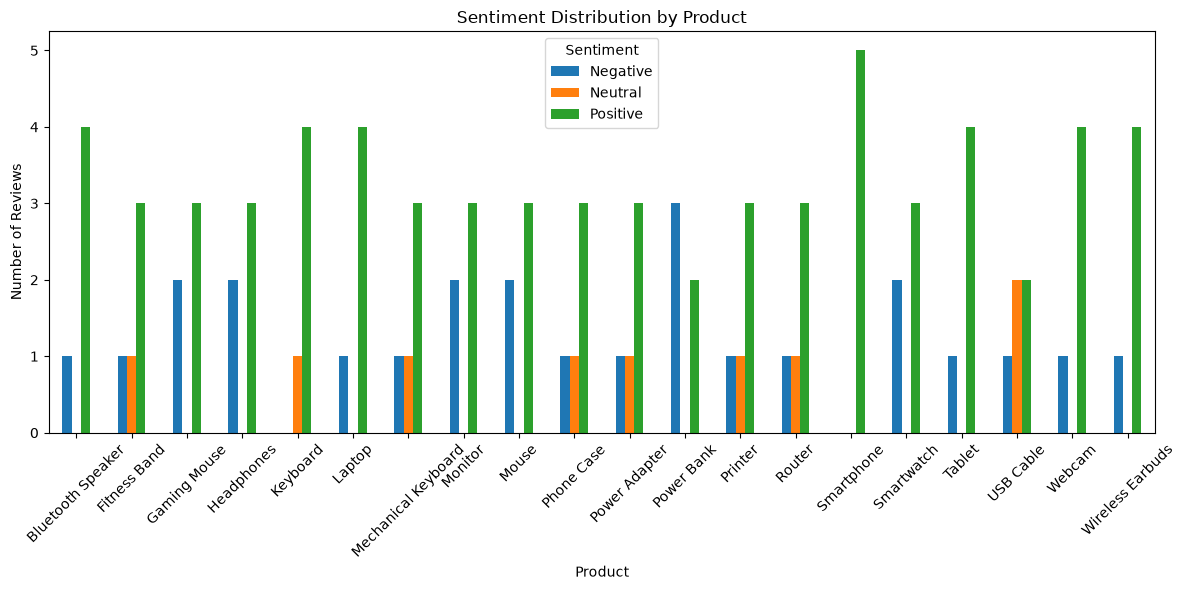

In [21]:
product_sentiment.plot(kind="bar", figsize=(12, 6))

plt.title("Sentiment Distribution by Product")
plt.xlabel("Product")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [22]:
rating_sentiment = pd.crosstab(df["Rating"], df["Sentiment"])

rating_sentiment


Sentiment,Negative,Neutral,Positive
Rating,,,
1,7,6,2
2,9,0,6
3,9,2,11
4,0,1,9
5,0,0,38


In [23]:
negative_reviews = df[df["Sentiment"] == "Negative"]

negative_reviews[["Product", "Review", "Rating", "Emotion"]]

,Product,Review,Rating,Emotion
3,Wireless Earbuds,Stopped working after one week. Very disappoin...,1,Sadness
11,Laptop,The laptop is slow when running multiple appli...,2,Neutral
16,Headphones,The sound is average and the ear cushions are ...,3,Neutral
17,Headphones,Terrible product. The left side stopped working.,1,Anger
21,Smartwatch,"The battery lasts only one day, which is disap...",2,Anger
23,Smartwatch,The app crashes frequently and syncing is frus...,1,Anger
31,Mouse,The scroll wheel feels loose.,2,Neutral
33,Mouse,Stopped connecting randomly. Not happy with it.,1,Joy
37,Tablet,The tablet became extremely slow after a few w...,2,Neutral
41,Power Bank,It is bulky but works as expected.,3,Neutral
